# From a Grouper event to a classifier window

This notebook starts with **one saved S/N-map chunk and its Grouper event**.
It uses the same PIRATE map loader, GPU argmax decoder, and peakfinder geometry
as the search pipeline. Run it in your built PIRATE environment with CuPy and
an NVIDIA GPU. ASDF reading and plotting use the CPU; map arrays, decoding,
and classifier-window extraction use the GPU.

The example injected a broadband FRB on beam 1 with DM 500 pc cm^-3,
Gaussian sigma 1 ms and S/N 50, arriving at 40 s at 300 MHz. Those are the
**injection parameters**; all event coordinates below come from the recovered
Grouper catalog.

The route is:
`event -> beam/tree/source chunk -> (DM row, time column) -> window + masks`.
The catalog was produced from the full observation. We retain only the map
chunk needed to inspect this event, including its argmax tokens and metadata.
The observation and search do not need to be regenerated to run this notebook.


In [1]:
from pathlib import Path
from copy import deepcopy
import operator
import sys

import asdf
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

%matplotlib inline

folders = (Path.cwd(), Path.cwd() / "AIclassifier")
example_dir = next((p for p in folders if (p / "data/events.asdf").is_file()), None)
if example_dir is None:
    raise FileNotFoundError("Run from AIclassifier/ or the repository root, with data/ present.")
data_dir = example_dir / "data"

# Support a compiled checkout as well as an installed PIRATE package.
repo_dir = example_dir.parent
if (repo_dir / "pirate_frb").is_dir():
    sys.path.insert(0, str(repo_dir))

from pirate_frb.OfflineMapReader import OfflineMapReader
from pirate_frb.GpuArgmaxDecoder import GpuArgmaxDecoder
from pirate_frb.BowtiePeakfinding import GpuRawCandidates, PeakFinderGeometry
from pirate_frb.TriggerCatalog import validate_trigger_catalog_tree

CUDA_DEVICE_ID = 0  # Logical device index in the current CUDA environment.
cp.cuda.Device(CUDA_DEVICE_ID).use()
device_name = cp.cuda.runtime.getDeviceProperties(CUDA_DEVICE_ID)["name"]
if isinstance(device_name, bytes):
    device_name = device_name.decode()
print(f"PIRATE functions loaded; CUDA device {CUDA_DEVICE_ID}: {device_name}")


PIRATE functions loaded; CUDA device 0: NVIDIA A40


## 1. Read the Grouper event

`event_row` is a row in the catalog. `event_id` is its recorded identifier;
neither is a beam index. Beam IDs are labels, so **beam 1 does not mean array
position 1**. The loader returns `(beam, DM, time)` arrays; select the
beam axis using `maps.beam_ids` before indexing the two-dimensional tree map.

`tree` chooses a producer tree. `source_chunk_index` chooses the representative's
actual source map. `grouping_window_id` identifies the grouping operation; its
owner chunk can differ from the representative's source chunk.


In [2]:
event_row = 0

with asdf.open(data_dir / "events.asdf") as catalog:
    validate_trigger_catalog_tree(catalog.tree)
    columns = catalog.tree["events"]
    if not 0 <= event_row < len(columns["event_id"]):
        raise IndexError("event_row is outside this catalog")
    event = {name: values[event_row].item() for name, values in columns.items()}
    catalog_metadata = deepcopy(catalog.tree["metadata"])

beam_id = int(event["beam_id"])
tree_id = int(event["tree"])
source_chunk = int(event["source_chunk_index"])
idm, itime = int(event["idm"]), int(event["itime"])
window_record = next(w for w in catalog_metadata["grouping_windows"]
                     if w["grouping_window_id"] == event["grouping_window_id"])

summary = [
    ("Event ID", event["event_id"]),
    ("Beam ID", beam_id),
    ("Tree index", tree_id),
    ("Source chunk", source_chunk),
    ("Grouping owner chunk", window_record["owner_source_chunk_index"]),
    ("DM row: idm", idm),
    ("Time column: itime", itime),
    ("Recovered DM (pc cm^-3)", f"{event['dm']:.9f}"),
    ("Recovered S/N", event["snr"]),
    ("Recovered boxcar width (ms)", event["width_ms"]),
    ("Edge flags", event["edge_flags"]),
    ("Grouping timed out", event["grouping_timed_out"]),
]
display(Markdown("| Field | Value |\n| --- | --- |\n" +
                 "\n".join(f"| {key} | {value} |" for key, value in summary)))


| Field | Value |
| --- | --- |
| Event ID | 0 |
| Beam ID | 1 |
| Tree index | 0 |
| Source chunk | 19 |
| Grouping owner chunk | 19 |
| DM row: idm | 1385 |
| Time column: itime | 72 |
| Recovered DM (pc cm^-3) | 499.997795211 |
| Recovered S/N | 46.0625 |
| Recovered boxcar width (ms) | 2.9951999999999996 |
| Edge flags | 0 |
| Grouping timed out | False |

## 2. Locate and verify the exact source pixel

Select the beam and source chunk recorded in the event. `OfflineMapReader`
validates the saved maps and reconstructs their producer plan;
`load_beam_chunk` uploads the requested maps to the selected GPU. The result
contains one CuPy array per tree, preserving each tree's native resolution.

Each S/N pixel is the maximum over finer trial positions and matched-filter
widths. Its `argmax` token records the winning trial. We check both against
the event before extracting a window. Promote S/N from float16 to float32
on the GPU for decoding and classifier input; no resampling is applied.


In [3]:
loader = OfflineMapReader(data_dir, cuda_device_id=CUDA_DEVICE_ID)
producer = catalog_metadata["producer"]
for field in ("config_yaml", "plan_yaml", "argmax_encoding"):
    assert getattr(loader, field) == producer[field], f"Producer mismatch: {field}"
assert loader.dcores == tuple(producer["dcores"])

maps = loader.load_beam_chunk((beam_id,), source_chunk)
beam_index = maps.beam_ids.index(beam_id)
snr = maps.snr_by_tree[tree_id][beam_index].astype(cp.float32)
argmax = maps.argmax_by_tree[tree_id][beam_index]
plan = loader.plan
ndm, ntime = snr.shape
nt_in = loader.nt_in
time_sample_ms = loader.time_sample_ms
producer_start_chunk = loader.producer_start_by_beam[beam_id]

assert argmax.shape == snr.shape == loader.tree_shapes[tree_id]
assert 0 <= idm < ndm and 0 <= itime < ntime
assert snr[idm, itime].item() == event["snr"]
assert argmax[idm, itime].item() == event["argmax_token"]
print(f"Beam {beam_id} is array position {beam_index}; source chunk {maps.source_chunk_index}")
print(f"GPU S/N and argmax shape: {snr.shape}; tree {tree_id}")
print(f"Verified snr[{idm}, {itime}] = {snr[idm, itime].item()}")
print(f"Verified argmax token = 0x{argmax[idm, itime].item():08x}")


Beam 1 is array position 0; source chunk 19
GPU S/N and argmax shape: (4096, 128); tree 0
Verified snr[1385, 72] = 46.0625
Verified argmax token = 0x00020301


## 3. Decode with the same functions as the Grouper

`PeakFinderGeometry.from_plan` supplies this tree's native DM and time spacing
and its full-band bowtie. Use the producer's `dcores` and the catalog's recorded
peakfinder settings, as the search does.

**Use the catalog's `idm` and `itime` directly to find the pixel.** Its physical
DM and arrival time include finer trial positions, profile widths, and timing
offsets. `GpuArgmaxDecoder.decode` recovers those values from the source pixel
and its token. We pass a one-row `GpuRawCandidates` batch and verify that the
decoded result agrees with the saved event.

`toa_sample_abs` is a full-resolution sample coordinate from FPGA sequence
zero, referenced to the low edge of the complete observing band. Subtract the
producer-start coordinate to express it relative to this observation.


In [4]:
processing = catalog_metadata["processing"]
geometry = PeakFinderGeometry.from_plan(
    plan, tree_id, dcore=loader.dcores[tree_id],
    dm_reach=int(processing["dm_reach_by_tree"][tree_id]),
    waist_bins=int(processing["waist_bins_by_tree"][tree_id]),
)
dm_step, time_step_s = geometry.dm_step, geometry.time_step_s

decoder = GpuArgmaxDecoder(plan, cuda_device_id=CUDA_DEVICE_ID, dcores=loader.dcores)
raw = GpuRawCandidates(
    beam_id=cp.asarray([beam_id], dtype=cp.int32),
    source_chunk_index=cp.asarray([source_chunk], dtype=cp.int64),
    tree=cp.asarray([tree_id], dtype=cp.int32),
    idm=cp.asarray([idm], dtype=cp.int32),
    itime=cp.asarray([itime], dtype=cp.int32),
    snr=snr[idm:idm+1, itime:itime+1].reshape(-1),
    argmax_token=argmax[idm:idm+1, itime:itime+1].reshape(-1),
    edge_flags=cp.asarray([event["edge_flags"]], dtype=cp.uint8),
)
decoded = decoder.decode(raw)
assert decoded.valid_mask[0].item(), "The source token did not decode successfully"
assert decoded.primary_tree_index[0].item() == event["primary_tree_index"]
for field in ("dm", "toa_sample_abs", "width_samp", "width_ms", "freq_lo_MHz", "freq_hi_MHz"):
    np.testing.assert_allclose(getattr(decoded, field)[0].item(), event[field], rtol=1e-12)

print(f"DM spacing: {dm_step:.9f} pc cm^-3 per row")
print(f"Time spacing: {time_step_s * 1000:.6f} ms per column")
print(f"GPU-decoded DM: {decoded.dm[0].item():.9f} pc cm^-3; matches catalog")
if producer_start_chunk is not None:
    arrival_s = ((decoded.toa_sample_abs[0].item() - producer_start_chunk * nt_in)
                 * time_sample_ms * 1e-3)
    print(f"Arrival: {arrival_s:.9f} s from producer start at {geometry.reference_freq_mhz:g} MHz")
else:
    print("Producer start is unknown; retain the absolute sample coordinate.")
print(f"Source chunk stays numbered {source_chunk}; it is not renumbered to zero in this sample.")


DM spacing: 0.360971151 pc cm^-3 per row
Time spacing: 15.974400 ms per column
GPU-decoded DM: 499.997795211 pc cm^-3; matches catalog
Arrival: 40.000066415 s from producer start at 300 MHz
Source chunk stays numbered 19; it is not renumbered to zero in this sample.


## 4. See the map and the neighborhood

The white cross marks the verified representative pixel. Both plots use the
native array coordinates: DM rows vertically and time columns horizontally.
The right panel zooms in without regridding the data.

Only the plot receives a host copy via `cp.asnumpy`; `snr` stays on the GPU.


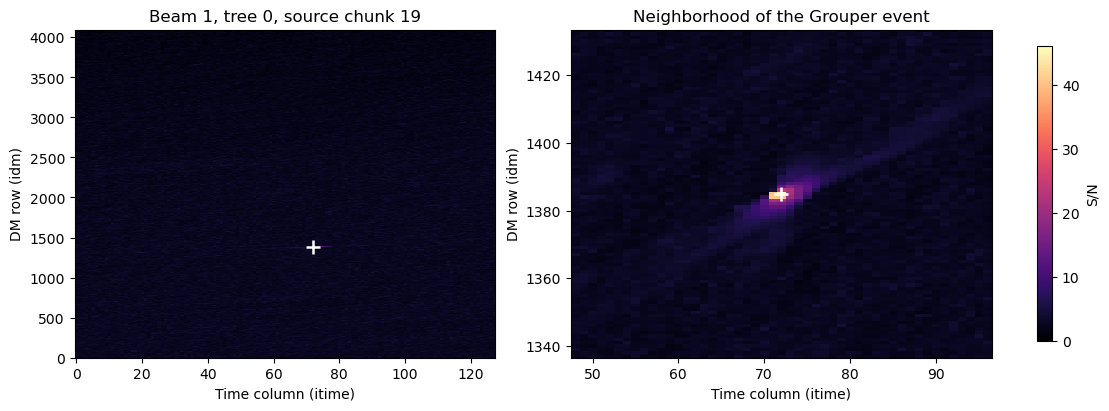

In [5]:
snr_plot = cp.asnumpy(snr)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax in axes:
    image = ax.imshow(snr_plot, origin="lower", aspect="auto", interpolation="nearest",
                      cmap="magma", vmin=0, vmax=event["snr"])
    ax.scatter(itime, idm, marker="+", c="white", s=100, linewidths=1.8)
    ax.set_xlabel("Time column (itime)")
    ax.set_ylabel("DM row (idm)")
axes[0].set_title(f"Beam {beam_id}, tree {tree_id}, source chunk {source_chunk}")
axes[1].set_xlim(itime - 24.5, itime + 24.5)
axes[1].set_ylim(idm - 48.5, idm + 48.5)
axes[1].set_title("Neighborhood of the Grouper event")
fig.colorbar(image, ax=axes, label="S/N", shrink=0.9)
plt.show()


## 5. Extract a window without wrapping at the edges

This small classifier helper takes CuPy source arrays and exact event indices.
It performs only slicing and padding on the GPU; geometry and decoding come
from the PIRATE functions above. It returns
an odd-sized rectangle centered on the event, together with absolute map indices
and a validity mask. This sample contains only one chunk: out-of-chunk pixels
are NaN and invalid, not silently wrapped, reflected, or filled with noise.
A token of `0xffffffff` means no winning trial and is invalid as well.


In [6]:
def integer_index(value, name, minimum=0):
    """Require a non-Boolean integer index at or above the given minimum."""
    if isinstance(value, (bool, np.bool_)):
        raise TypeError(f"{name} must be an integer, not bool")
    value = operator.index(value)
    if value < minimum:
        raise ValueError(f"{name} must be at least {minimum}")
    return value


def extract_window(snr, argmax, idm, itime, dm_radius, time_radius):
    """Copy a native GPU window; mark missing or invalid pixels with NaN and a mask.

    Arrays have axis order (DM, time) and must be on the current CUDA device.
    Centres and radii are host integers; all returned arrays remain on the GPU.
    """
    if not isinstance(snr, cp.ndarray) or not isinstance(argmax, cp.ndarray):
        raise TypeError("S/N and argmax must be CuPy arrays")
    if snr.ndim != 2 or argmax.shape != snr.shape:
        raise ValueError("S/N and argmax must have the same two-dimensional shape")
    if snr.dtype.kind != "f" or argmax.dtype != cp.dtype(cp.uint32):
        raise TypeError("S/N must be floating point and argmax must be uint32")
    if snr.device.id != cp.cuda.runtime.getDevice() or argmax.device.id != snr.device.id:
        raise ValueError("Both maps must be on the current CUDA device")
    idm, itime = integer_index(idm, "idm"), integer_index(itime, "itime")
    dm_radius = integer_index(dm_radius, "dm_radius")
    time_radius = integer_index(time_radius, "time_radius")
    if idm >= snr.shape[0] or itime >= snr.shape[1]:
        raise IndexError("the event centre is outside this map")

    row_start, col_start = idm - dm_radius, itime - time_radius
    rows = cp.arange(row_start, idm + dm_radius + 1, dtype=cp.int64)
    cols = cp.arange(col_start, itime + time_radius + 1, dtype=cp.int64)
    pixels = cp.full((rows.size, cols.size), cp.nan, dtype=cp.float32)
    tokens = cp.full(pixels.shape, 0xffffffff, dtype=cp.uint32)
    r0, r1 = max(row_start, 0), min(idm + dm_radius + 1, snr.shape[0])
    c0, c1 = max(col_start, 0), min(itime + time_radius + 1, snr.shape[1])
    destination = (slice(r0 - row_start, r1 - row_start),
                   slice(c0 - col_start, c1 - col_start))
    pixels[destination] = snr[r0:r1, c0:c1]
    tokens[destination] = argmax[r0:r1, c0:c1]
    valid = cp.isfinite(pixels) & (tokens != cp.uint32(0xffffffff))
    pixels[~valid] = cp.nan
    return {
        "snr": pixels, "argmax": tokens, "valid_mask": valid,
        "dm_indices": rows, "time_indices": cols,
        "center_index": (dm_radius, time_radius),
    }


## 6. Use PIRATE's bowtie in this tree's native pixels

`geometry.full_band_bowtie` is the CuPy mask constructed by
`PeakFinderGeometry.from_plan` in section 3, using the recorded DM reach and
waist. Both offline and online grouping use this same geometry class. There
is no separate bowtie formula in the notebook.

The geometry includes PIRATE's symmetric time crop when the requested
footprint exceeds one native chunk. Its requested and effective time radii
remain available for inspection. To explore a different footprint, change
`dm_reach` or `waist_bins` in the geometry call and rerun the following cells.

This is the peakfinder's comparison footprint. The classifier can use the
complete rectangle, the bowtie mask, or both.


In [7]:
bowtie_mask = geometry.full_band_bowtie
window = extract_window(snr, argmax, idm, itime,
                        geometry.dm_radius, geometry.time_radius)
selected_mask = bowtie_mask & window["valid_mask"]
centre = window["center_index"]
assert window["snr"][centre].item() == event["snr"]
assert window["argmax"][centre].item() == event["argmax_token"]
assert selected_mask[centre].item()
print(f"GPU window shape: {window['snr'].shape}; centre in window: {centre}")
print(f"Time radius: requested {geometry.requested_time_radius}, effective {geometry.time_radius} columns")
print(f"Available valid pixels: {window['valid_mask'].sum().item()}/{window['valid_mask'].size}")
print(f"Bowtie pixels: {bowtie_mask.sum().item()}; usable bowtie pixels: {selected_mask.sum().item()}")


GPU window shape: (17, 19); centre in window: (8, 9)
Time radius: requested 9, effective 9 columns


Available valid pixels: 323/323
Bowtie pixels: 91; usable bowtie pixels: 91


## 7. Inspect what the classifier receives

The axes below show offsets from the **representative map pixel**, using the
native DM-row and time-column spacings. They are not an independent decoding
of the precise pulse centre. The middle panel separates the bowtie geometry
from the data: black pixels are selected. Grey in the native-window panel means
unavailable or invalid data. In the selected-pixels panel, grey also hides valid
pixels outside the bowtie.


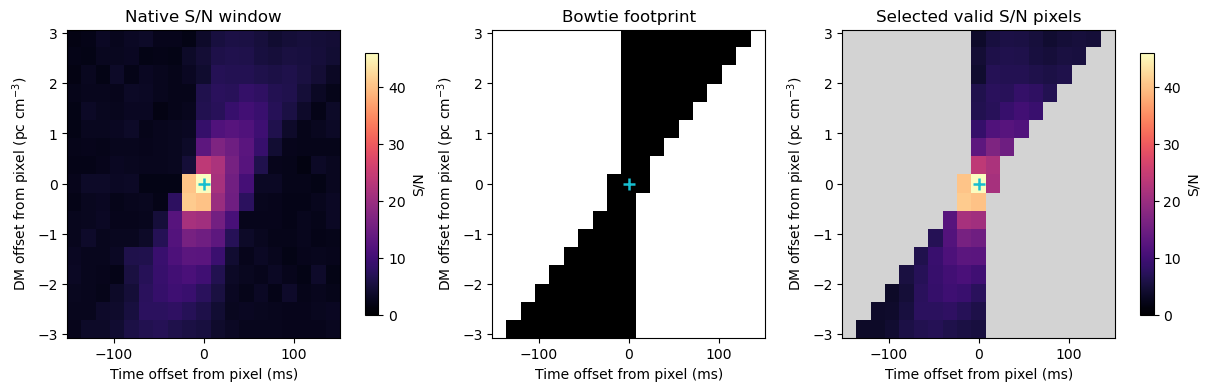

In [8]:
dm_offsets = cp.asnumpy(window["dm_indices"] - idm) * dm_step
time_offsets_ms = cp.asnumpy(window["time_indices"] - itime) * time_step_s * 1000
extent = [time_offsets_ms[0] - time_step_s * 500,
          time_offsets_ms[-1] + time_step_s * 500,
          dm_offsets[0] - dm_step / 2, dm_offsets[-1] + dm_step / 2]
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("lightgrey")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, values, title in zip(
        axes, (cp.asnumpy(window["snr"]), cp.asnumpy(bowtie_mask),
               cp.asnumpy(cp.where(selected_mask, window["snr"], cp.nan))),
        ("Native S/N window", "Bowtie footprint", "Selected valid S/N pixels")):
    is_mask = ax is axes[1]
    image = ax.imshow(values, origin="lower", aspect="auto", interpolation="nearest",
                      extent=extent, cmap="Greys" if is_mask else cmap,
                      vmin=0, vmax=1 if is_mask else event["snr"])
    ax.scatter(0, 0, marker="+", c="tab:cyan", s=80, linewidths=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time offset from pixel (ms)")
    ax.set_ylabel("DM offset from pixel (pc cm$^{-3}$)")
    if not is_mask:
        fig.colorbar(image, ax=ax, label="S/N", shrink=0.85)
plt.show()


## 8. A small, explicit classifier input

Keep the validity mask even if missing pixels are replaced by zero for a model.
A zero introduced for storage is not an observed zero-S/N pixel. Keep the
bowtie mask separate: it selects a footprint, whereas the validity mask records
which samples are usable.

The dictionary leaves axis order `(DM, time)` explicit and applies no model
normalization, resizing, or training framework assumptions.

The numerical arrays remain CuPy arrays on the GPU. If a consumer requires
NumPy, explicitly copy the particular array with `cp.asnumpy(...)` at that
boundary, as the plotting cells do.


In [9]:
classifier_sample = {
    "snr": cp.where(window["valid_mask"], window["snr"], 0).astype(cp.float32),
    "valid_mask": window["valid_mask"].copy(),
    "bowtie_mask": bowtie_mask.copy(),
    "argmax": window["argmax"].copy(),
    "event": dict(event),
    "dm_indices": window["dm_indices"].copy(),
    "time_indices": window["time_indices"].copy(),
    "center_index": centre,
    "axis_order": ("dm", "time"),
    "dm_step": dm_step,
    "time_step_s": time_step_s,
}
assert classifier_sample["dm_indices"][centre[0]] == idm
assert classifier_sample["time_indices"][centre[1]] == itime
assert cp.isfinite(classifier_sample["snr"]).all()
print({key: (value.shape, str(value.dtype))
       for key, value in classifier_sample.items() if isinstance(value, cp.ndarray)})
print(f"Event-to-pixel-to-window checks passed on CUDA device {snr.device.id}.")


{'snr': ((17, 19), 'float32'), 'valid_mask': ((17, 19), 'bool'), 'bowtie_mask': ((17, 19), 'bool'), 'argmax': ((17, 19), 'uint32'), 'dm_indices': ((17,), 'int64'), 'time_indices': ((19,), 'int64')}
Event-to-pixel-to-window checks passed on CUDA device 0.


## 9. What happens at a chunk boundary?

Our FRB window fits entirely inside chunk 19. As a small check, move a window
to time column 0 of the same map: its left side must stay missing, not wrap to
the end of the array. This check is about the extraction function, not another
detected event.

For a real event requiring those columns, load chunk 18 with the same beam,
tree, and producer metadata. They cannot be recovered from this sample. Missing
packaged context is different from a physical acquisition boundary; use the
catalog's event flags and producer-start metadata to assess those conditions.


In [10]:
boundary = extract_window(snr, argmax, idm, 0, dm_radius=2, time_radius=3)
assert not boundary["valid_mask"][:, :3].any()
assert cp.isnan(boundary["snr"][:, :3]).all()
assert cp.array_equal(boundary["snr"][:, 3:], snr[idm-2:idm+3, :4])
print("Boundary check passed: three unavailable columns are marked invalid.")


Boundary check passed: three unavailable columns are marked invalid.


## Where this connects to PIRATE

- [Simple offline/online example](../examples/simple_frb/README.md): regenerate
  the observation, maps, and event catalog.
- [OfflineMapReader](../pirate_frb/OfflineMapReader.py): load native tree maps
  into the GPU pipeline.
- [BowtiePeakfinding](../pirate_frb/BowtiePeakfinding.py): full-band bowtie and streaming
  peak extraction; see `build_full_band_bowtie` and `PeakFinderGeometry.from_plan`.
- [GpuArgmaxDecoder](../pirate_frb/GpuArgmaxDecoder.py): decode the raw indices
  and token using the exact producer plan and `dcores`.
- [TriggerCatalog](../pirate_frb/TriggerCatalog.py): event fields and provenance.
- [GrouperPipeline](../pirate_frb/GrouperPipeline.py): `GrouperSetup` constructs
  the same geometry and decoder for offline and online searches.
- [OnlineGrouper](../pirate_frb/OnlineGrouper.py): the live adapter. Its printed
  event-monitor output does not carry the complete raw-pixel identity used here.

For live classifier integration, retain the representative's source coordinates
and arrange access to its map while that data are still available. GPU output
views must be copied or consumed before their producer context releases them.
